In [1]:
import psycopg2
from psycopg2 import sql
from datetime import datetime, timedelta
import random
import pytz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Creates database with 15m Products

In [ ]:
# Set the Europe/Berlin timezone
berlin_tz = pytz.timezone('Europe/Berlin')

# Function to round datetime object to the nearest full hour
def round_to_full_hour(dt):
    """
    Randomly assigns the input datetime `dt` to one of the four quarter-hour marks 
    (:00, :15, :30, or :45) of the same hour.

    Parameters:
        dt (datetime.datetime): A timezone-aware or naive datetime object.

    Returns:
        datetime.datetime: Modified datetime with a randomly selected quarter-hour.
    """
    # If the minutes are 30 or more, round up to the next hour
    if dt.minute >= 30:
        dt = dt + timedelta(hours=1)
    
    # Set minutes, seconds, and microseconds to zero
    return dt.replace(minute=random.choice([0,15,30,45]), second=0, microsecond=0)

# Function to generate a random timezone-aware timestamp in 2022, rounded to the nearest full hour
def random_time_in_2022():
    start = berlin_tz.localize(datetime(2022, 1, 1))  # Timezone-aware datetime
    end = berlin_tz.localize(datetime(2023, 1, 1, 23, 59, 59))  # Full year 2022

    # Calculate the total number of hours between start and end
    total_hours = int((end - start).total_seconds() // 3600)

    # Generate a random number of hours
    random_hours = random.randint(0, total_hours)

    # Add the random number of hours to the start date
    random_time = start + timedelta(hours=random_hours)

    # Round to the nearest full hour
    return round_to_full_hour(random_time)

# Function to generate a deliverystart within the next 16 hours, ensuring deliverystart is a full hour
def random_deliverystart(executiontime):
    # Round the execution time to the nearest full hour (if needed)
    rounded_executiontime = round_to_full_hour(executiontime)
    
    # Add a random number of full hours between 0 and 15 (inclusive)
    random_hours = random.randint(0, 15)
    
    # Calculate deliverystart, which will always be at a full hour
    deliverystart = rounded_executiontime + timedelta(hours=random_hours)
    
    # Ensure deliverystart is rounded to the full hour
    return round_to_full_hour(deliverystart)

# Generate and insert fake transactions into the transactions_intraday_de table
def insert_fake_transactions(df:pd.DataFrame, num_transactions=100 ):
    count = 0
    c = 1
    while count < num_transactions:
        # Generate the base execution time, timezone-aware and rounded to quarter hour 
        base_executiontime = random_time_in_2022()

        # Insert the first transaction with the base execution time
        for i in range(6):  # Insert the base transaction + 5 more transactions within the next 5 minutes
            if i == 0:
                executiontime = base_executiontime
            else:
                # Add a random number of minutes and round the executiontime to the nearest minute
                executiontime = (base_executiontime + timedelta(minutes=i)).replace(second=0, microsecond=0)

            # Ensure executiontime is rounded to a quarter hour
            executiontime = round_to_full_hour(executiontime)

            # Set deliverystart to be within the next 16 hours and ensure it's on quarter hour
            deliverystart = random_deliverystart(executiontime)
            deliveryend = deliverystart + timedelta(minutes=15)

            price = round(random.uniform(20, 100), 2)  # Random price between 20 and 100
            volume = round(random.uniform(1, 10), 2)  # Random volume between 1 and 10
            side = random.choice(['BUY', 'SELL'])  # Randomly choose 'buy' or 'sell'
            product = random.choice(['XBID_Quarter_Hour_Power', 'Intraday_Quarter_Hour_Power'])  # Randomly choose the product
            df.loc[count*6 + i,:] = [executiontime, deliverystart, deliveryend, price, volume, side, product]
            """
            # Insert the transaction into the transactions_intraday_de table
            cur.execute(
                sql.SQL("INSERT INTO transactions_intraday_de (executiontime, deliverystart, deliveryend, price, volume, side, product) VALUES (%s, %s, %s, %s, %s, %s, %s);"),
                [executiontime, deliverystart, deliveryend, price, volume, side, product]
            )
            """
            
            if count // 10_000 >= c :
                print(f"Finished {count} Transactions",[executiontime, deliverystart, deliveryend, price, volume, side, product])
                c=c+1
        count += 1
            
            
    # Commit the transaction
    #sconn.commit()
    
    print(f"{num_transactions} fake transactions inserted successfully!")


# Insert 1,000,000 fake transactions
datapoints = 1_000_000

df_fake_transactions = pd.DataFrame(
    index=range(datapoints * 6),  # Preallocate rows
    columns=["executiontime", "deliverystart", "deliveryend", "price", "volume", "side", "product"]
)
                                   
insert_fake_transactions(df_fake_transactions,datapoints)
df_fake_transactions = df_fake_transactions.astype({
    "executiontime": "datetime64[ns, Europe/Berlin]",
    "deliverystart": "datetime64[ns, Europe/Berlin]",
    "deliveryend": "datetime64[ns, Europe/Berlin]",
    "price": "float32",
    "volume": "float32"
}) 


10 fake transactions inserted successfully!


In [3]:
df_fake_transactions.head()

,executiontime,deliverystart,deliveryend,price,volume,side,product
0,2022-05-04 10:00:00+02:00,2022-05-05 02:45:00+02:00,2022-05-05 03:00:00+02:00,27.770000,4.36,BUY,Intraday_Quarter_Hour_Power
1,2022-05-04 10:30:00+02:00,2022-05-04 14:45:00+02:00,2022-05-04 15:00:00+02:00,72.629997,5.12,SELL,XBID_Quarter_Hour_Power
2,2022-05-04 10:30:00+02:00,2022-05-04 21:30:00+02:00,2022-05-04 21:45:00+02:00,54.259998,5.96,SELL,XBID_Quarter_Hour_Power
3,2022-05-04 10:30:00+02:00,2022-05-04 14:00:00+02:00,2022-05-04 14:15:00+02:00,63.480000,8.73,BUY,XBID_Quarter_Hour_Power
4,2022-05-04 10:45:00+02:00,2022-05-04 23:30:00+02:00,2022-05-04 23:45:00+02:00,62.590000,8.87,BUY,XBID_Quarter_Hour_Power


If you want to save the data

In [4]:
path_fake_data = os.path.join("../","./fake_data/transaction_data.parquet")
df_fake_transactions.sort_values("executiontime").to_parquet(path_fake_data)

<Axes: >

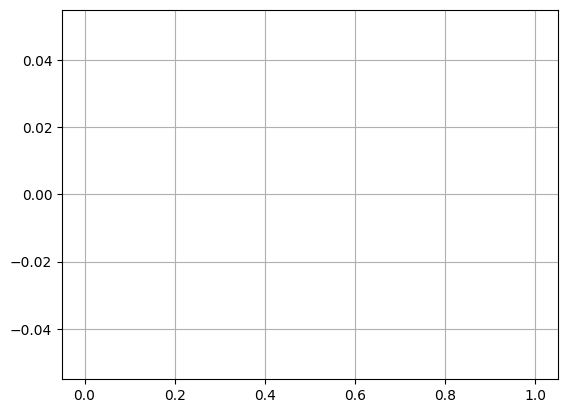

In [5]:
df_fake_transactions.set_index("executiontime").sort_index().loc["2022-01-01 10:00:00":"2022-01-01 16:00:00","price"].hist()